# Introduction to Computational Physics - Exercise Sheet 2

In [40]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import math
import time

## Part 1: Implemention
Implement linear interpolation and natural cubic spline interpolation, for data (xi,yi) with strictly increasing xi and return interpolated values at query points.

In [110]:
def linear_interpolation(data,query_xvalues):
    """function linearly interpolates between the data points (x_i,y_i) and returns values of the interpolated function 
    for given query points
    
    data: array (2,n) that describes data points (x_i,y_i) for i=0,...,n-1
    query_xvalues: array that describes x-values of query_points, all values need to be between x_0 and x_(n-1)"""
    
    x_data,y_data=data
    
    query_yvalues=np.zeros(len(query_xvalues))
    #find out where query points are located (between which x values)
    indices=np.searchsorted(x_data, query_xvalues)
    
    for i in range(len(indices)):
        query_yvalues[i]=y_data[indices[i]-1]+(y_data[indices[i]]-y_data[indices[i]-1])/(x_data[indices[i]]-x_data[indices[i]-1])*(query_xvalues[i]-x_data[indices[i]-1])
        
    return query_yvalues


def cubic_spline_interpolation(data,query_xvalues):
    """function interpolates between the data points (x_i,y_i) via cubic spines and returns values of the interpolated function 
    for given query points and spline coefficients
    
    data: array (2,n) that describes data points (x_i,y_i) for i=0,...,n-1
    query_xvalues: array that describes x-values of query_points, all values need to be between x_0 and x_(n-1)
    
    return query_yvalues, a,b,c,d"""
    
    x_data,y_data=data
    n=len(x_data)-1
    
    a=y_data
    b=np.zeros(n)
    c=np.zeros(n+1)
    d=np.zeros(n)
    
    #calculate all parameters with algorithm from script
    #step 1
    h=x_data[1:]-x_data[:-1]
    #step 2
    alpha=np.zeros(n)
    alpha[1:]=3/h[1:]*(a[2:]-a[1:-1])-3/h[:-1]*(a[1:-1]-a[:-2])
    #step 3
    l=np.zeros(n+1)
    l[0]=1
    mu=np.zeros(n+1)    
    z=np.zeros(n+1)
    #step 4
    for i in range(1,n):
        l[i]=2*(x_data[i+1]-x_data[i-1])-h[i-1]*mu[i-1]
        mu[i]=h[i]/l[i]
        z[i]=(alpha[i]-h[i-1]*z[i-1])/l[i]
    #step 5
    l[n]=1
    z[n]=0
    mu[n]=0
    #step 6
    for j in range(n-1,-1,-1):
        c[j]=z[j]-mu[j]*c[j+1]
        b[j]=(a[j+1]-a[j])/h[j]-h[j]/3*(c[j+1]+2*c[j])
        d[j]=(c[j+1]-c[j])/(3*h[j])
        
    
    indices = np.searchsorted(x_data, query_xvalues) - 1
    indices = np.clip(indices, 0, n-1)
    
    dx = query_xvalues - x_data[indices]
    
    query_yvalues = a[indices]+ b[indices] * dx+ c[indices] * dx**2+ d[indices] * dx**3
                     
    return query_yvalues, np.array([a[:-1],b,c[:-1],d])

### Test of linear interpolation

In [111]:
test_data=np.array([[0,2,4,7,9],[0,4,16,49,81]])
query_xvalues=np.array([1,3,5.5,6,7.8])

y=linear_interpolation(test_data,query_xvalues)

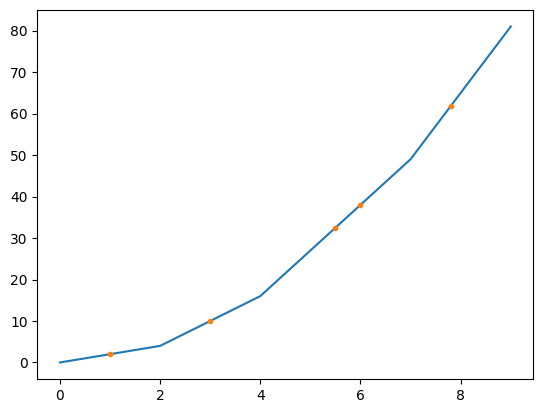

In [112]:
plt.plot(test_data[0],test_data[1])
plt.plot(query_xvalues,y,".")
plt.show()

### Test of cubic spline interpolation

In [113]:
query_xvalues=np.linspace(0.5,8.5)
y=cubic_spline_interpolation(test_data,query_xvalues)[0]

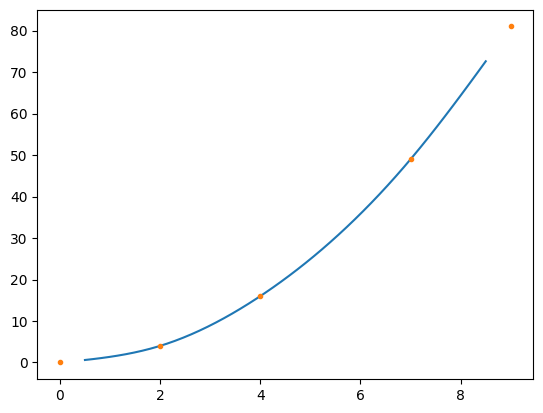

In [114]:
plt.plot(query_xvalues,y)
plt.plot(test_data[0],test_data[1],".")

plt.show()

## Part 2: Testing with simple data

In [115]:
simple_data=np.array([[0,1,2],[0,1,0]])

cubic_spline_interpolation(simple_data,np.array(1))

(1.0,
 array([[ 0. ,  1. ],
        [ 1.5,  0. ],
        [ 0. , -1.5],
        [-0.5,  0.5]]))

Therefore the splines are given by:

S_0(x) = 1.5x-0.5x^3and S_1(x) = 1-1.5(x-1)^2+0.5(x-1)^3


since:

S_0(1)=1=S_1(1), S_0'(1)=0=S_1'(1), S_0''(1)=-3=S_1''(1)

Interpolation is smooth until second derivative

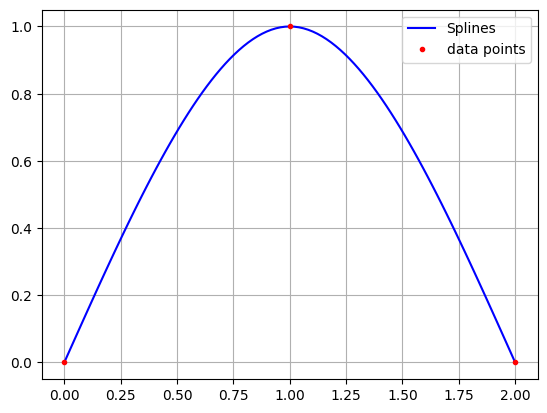

In [122]:
x1=np.linspace(0,1)
S1=1.5*x1-0.5*x1**3
x2=np.linspace(1,2)
S2=1-1.5*(x2-1)**2+0.5*(x2-1)**3

plt.plot(x1,S1,color="blue",label="Splines")
plt.plot(x2,S2,color="blue")

plt.plot(simple_data[0],simple_data[1],".",color="red",label="data points")

plt.grid()
plt.legend()
plt.show()

## Part 3: Interpolation in linear variables

In [168]:
M=np.array([0.5,1,1.5,2,3,5,10,20,40])
tau=np.array([56000,10000,3000,1300,400,100,20,5,3])
L=np.array([0.05,1.0,5,25,80,800,10000,100000,500000])
R=np.array([0.5,1,1.5,2,3,4,6,10,15])
T=np.array([3800,5800,7200,9000,12000,17000,25000,35000,45000])

In [169]:
query_xvalues=np.linspace(0.5,40,100)

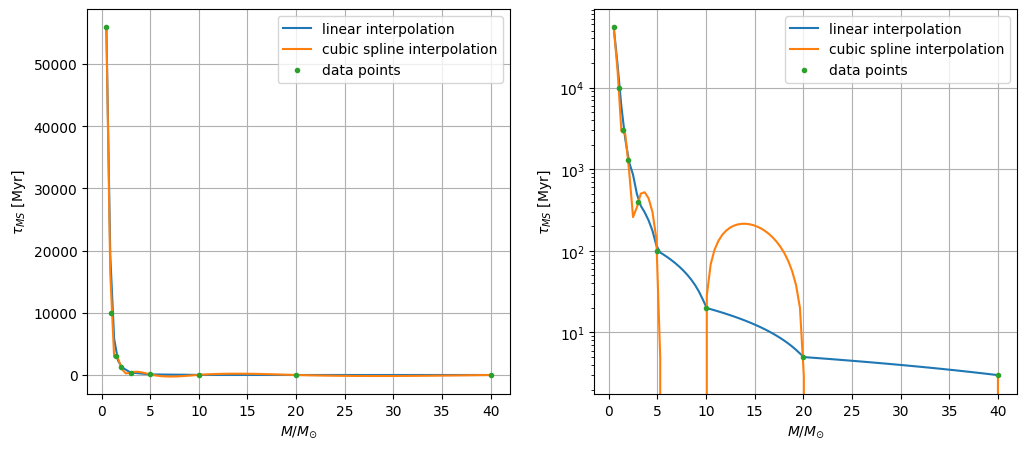

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(query_xvalues,linear_interpolation([M,tau],query_xvalues),label="linear interpolation")
axes[0].plot(query_xvalues,cubic_spline_interpolation([M,tau],query_xvalues)[0],label="cubic spline interpolation")

axes[0].plot(M,tau,".",label="data points")


axes[0].set_xlabel(r"$M/M_⊙$")
axes[0].set_ylabel(r"$\tau_{MS}$ [Myr]")

axes[0].legend()
axes[0].grid()


axes[1].plot(query_xvalues,linear_interpolation([M,tau],query_xvalues),label="linear interpolation")
axes[1].plot(query_xvalues,cubic_spline_interpolation([M,tau],query_xvalues)[0],label="cubic spline interpolation")

axes[1].plot(M,tau,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$\tau_{MS}$ [Myr]")
axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

plt.show()

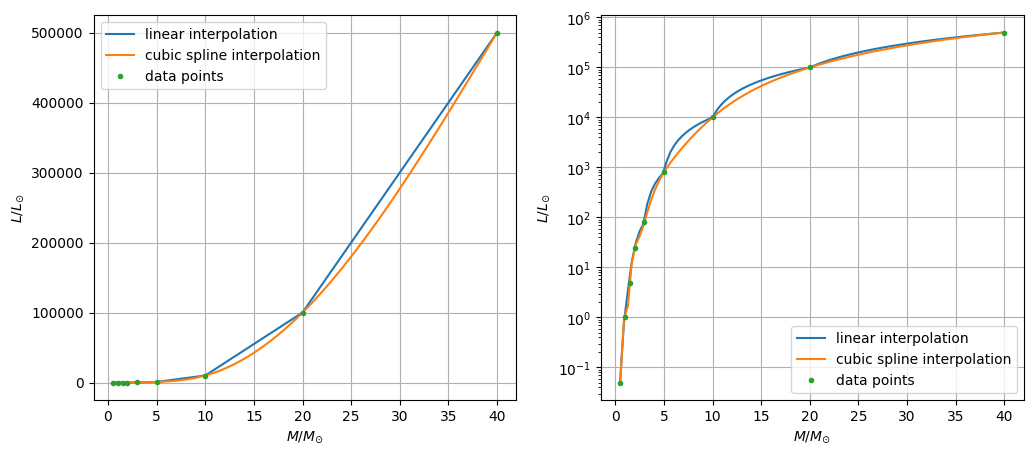

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(query_xvalues,linear_interpolation([M,L],query_xvalues),label="linear interpolation")
axes[0].plot(query_xvalues,cubic_spline_interpolation([M,L],query_xvalues)[0],label="cubic spline interpolation")

axes[0].plot(M,L,".",label="data points")


axes[0].set_xlabel(r"$M/M_⊙$")
axes[0].set_ylabel(r"$L/L_⊙$")

axes[0].legend()
axes[0].grid()


axes[1].plot(query_xvalues,linear_interpolation([M,L],query_xvalues),label="linear interpolation")
axes[1].plot(query_xvalues,cubic_spline_interpolation([M,L],query_xvalues)[0],label="cubic spline interpolation")

axes[1].plot(M,L,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$L/L_⊙$")
axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

plt.show()

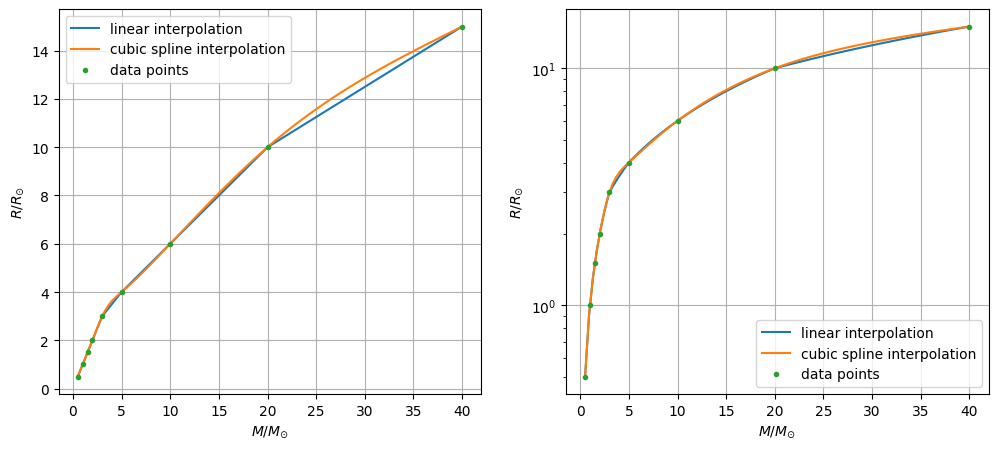

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(query_xvalues,linear_interpolation([M,R],query_xvalues),label="linear interpolation")
axes[0].plot(query_xvalues,cubic_spline_interpolation([M,R],query_xvalues)[0],label="cubic spline interpolation")

axes[0].plot(M,R,".",label="data points")


axes[0].set_xlabel(r"$M/M_⊙$")
axes[0].set_ylabel(r"$R/R_⊙$")

axes[0].legend()
axes[0].grid()


axes[1].plot(query_xvalues,linear_interpolation([M,R],query_xvalues),label="linear interpolation")
axes[1].plot(query_xvalues,cubic_spline_interpolation([M,R],query_xvalues)[0],label="cubic spline interpolation")

axes[1].plot(M,R,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$R/R_⊙$")
axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

plt.show()

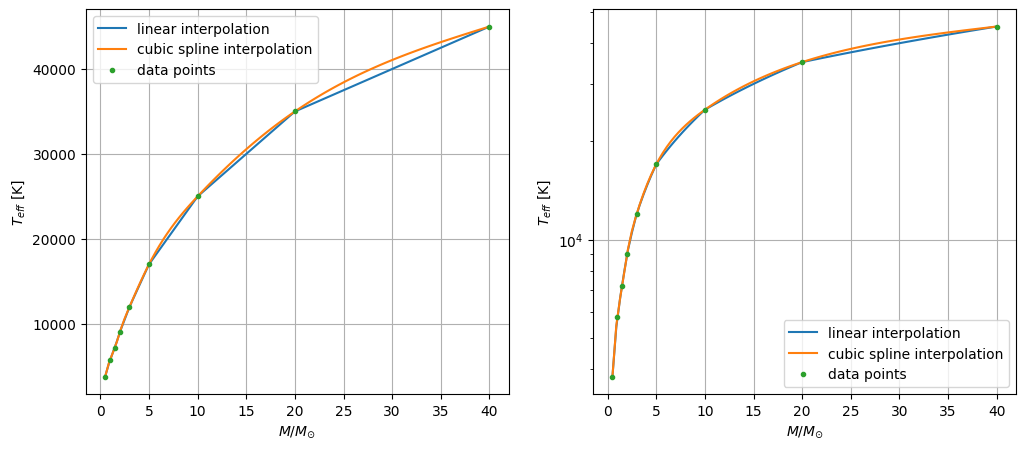

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(query_xvalues,linear_interpolation([M,T],query_xvalues),label="linear interpolation")
axes[0].plot(query_xvalues,cubic_spline_interpolation([M,T],query_xvalues)[0],label="cubic spline interpolation")

axes[0].plot(M,T,".",label="data points")


axes[0].set_xlabel(r"$M/M_⊙$")
axes[0].set_ylabel(r"$T_{eff}$ [K]")

axes[0].legend()
axes[0].grid()


axes[1].plot(query_xvalues,linear_interpolation([M,T],query_xvalues),label="linear interpolation")
axes[1].plot(query_xvalues,cubic_spline_interpolation([M,T],query_xvalues)[0],label="cubic spline interpolation")

axes[1].plot(M,T,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$T_{eff}$ [K]")
axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

plt.show()

### Comment:
For strongly decreasing functions both linear and cubic spines interpolations are badly represented, especially cubic splines!

For strongly increasing function cubic spines seem to be okay but linear interpolation are still badly represented.

## Part 4: Interpolation in logarithmic variables

In [173]:
logM=np.log10(M)
logtau=np.log10(tau)
logL=np.log10(L)
logR=np.log10(R)
logT=np.log10(T)

In [174]:
logquery_xvalues=np.log10(query_xvalues)

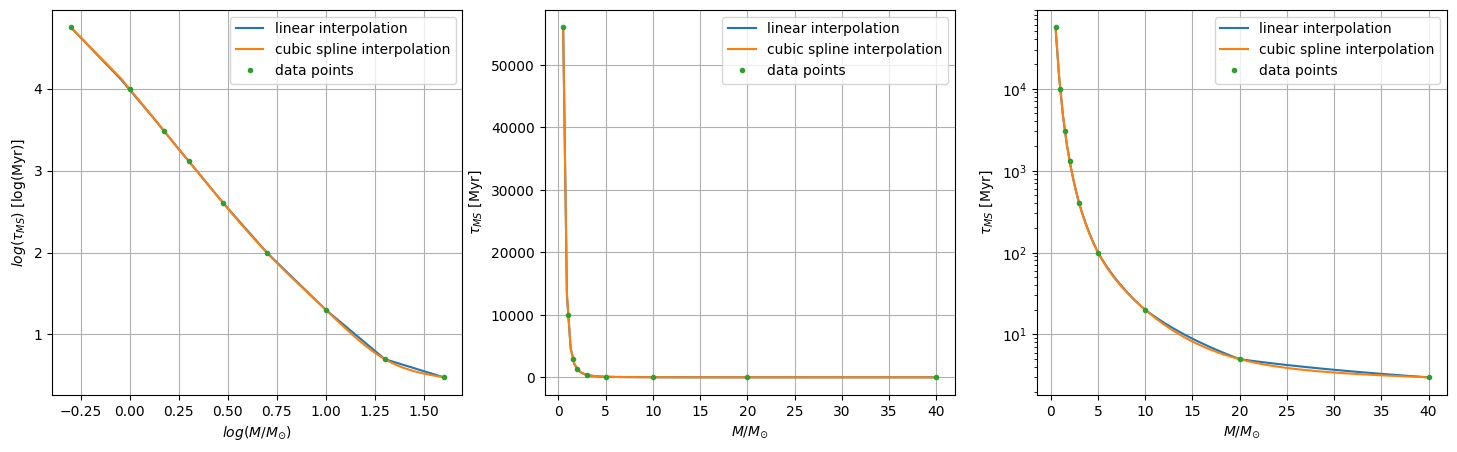

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x=logquery_xvalues
y1=linear_interpolation([logM,logtau],logquery_xvalues)
y2=cubic_spline_interpolation([logM,logtau],logquery_xvalues)[0]


axes[0].plot(x,y1,label="linear interpolation")
axes[0].plot(x,y2,label="cubic spline interpolation")

axes[0].plot(logM,logtau,".",label="data points")


axes[0].set_xlabel(r"$log(M/M_⊙)$")
axes[0].set_ylabel(r"$log(\tau_{MS})$ [log(Myr)]")

axes[0].legend()
axes[0].grid()

x=10**x
y1=10**y1
y2=10**y2


axes[1].plot(x,y1,label="linear interpolation")
axes[1].plot(x,y2,label="cubic spline interpolation")

axes[1].plot(10**logM,10**logtau,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$\tau_{MS}$ [Myr]")
#axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

axes[2].plot(x,y1,label="linear interpolation")
axes[2].plot(x,y2,label="cubic spline interpolation")

axes[2].plot(10**logM,10**logtau,".",label="data points")


axes[2].set_xlabel(r"$M/M_⊙$")
axes[2].set_ylabel(r"$\tau_{MS}$ [Myr]")
axes[2].set_yscale("log")

axes[2].legend()
axes[2].grid()

plt.show()

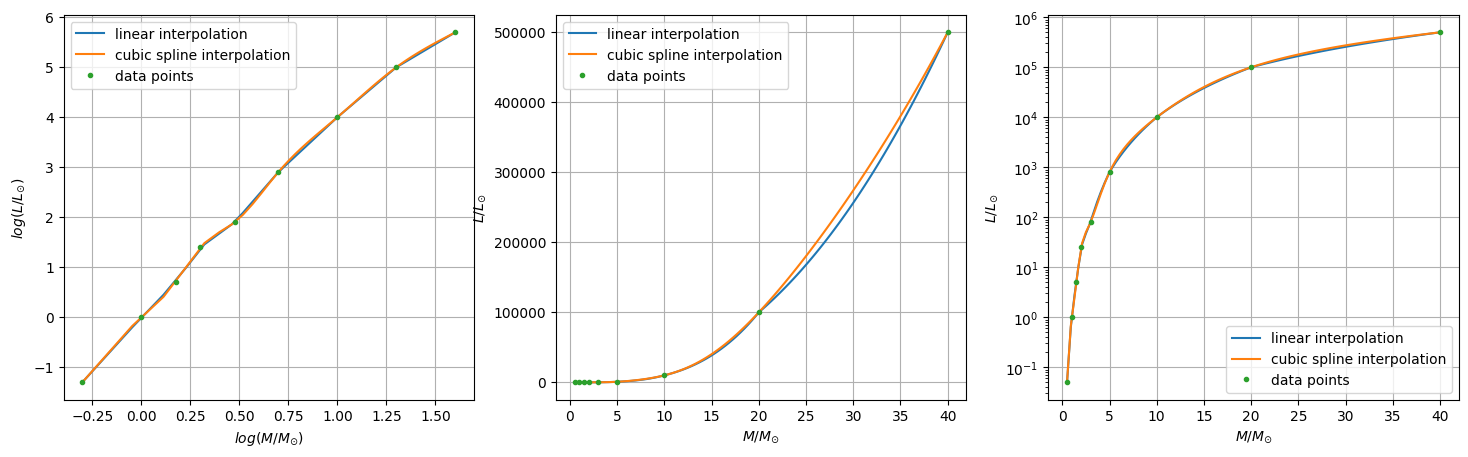

In [166]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x=logquery_xvalues
y1=linear_interpolation([logM,logL],logquery_xvalues)
y2=cubic_spline_interpolation([logM,logL],logquery_xvalues)[0]


axes[0].plot(x,y1,label="linear interpolation")
axes[0].plot(x,y2,label="cubic spline interpolation")

axes[0].plot(logM,logL,".",label="data points")


axes[0].set_xlabel(r"$log(M/M_⊙)$")
axes[0].set_ylabel(r"$log(L/L_⊙)$")

axes[0].legend()
axes[0].grid()

x=10**x
y1=10**y1
y2=10**y2


axes[1].plot(x,y1,label="linear interpolation")
axes[1].plot(x,y2,label="cubic spline interpolation")

axes[1].plot(10**logM,10**logL,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$L/L_⊙$")
#axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

axes[2].plot(x,y1,label="linear interpolation")
axes[2].plot(x,y2,label="cubic spline interpolation")

axes[2].plot(10**logM,10**logL,".",label="data points")


axes[2].set_xlabel(r"$M/M_⊙$")
axes[2].set_ylabel(r"$L/L_⊙$")
axes[2].set_yscale("log")

axes[2].legend()
axes[2].grid()

plt.show()

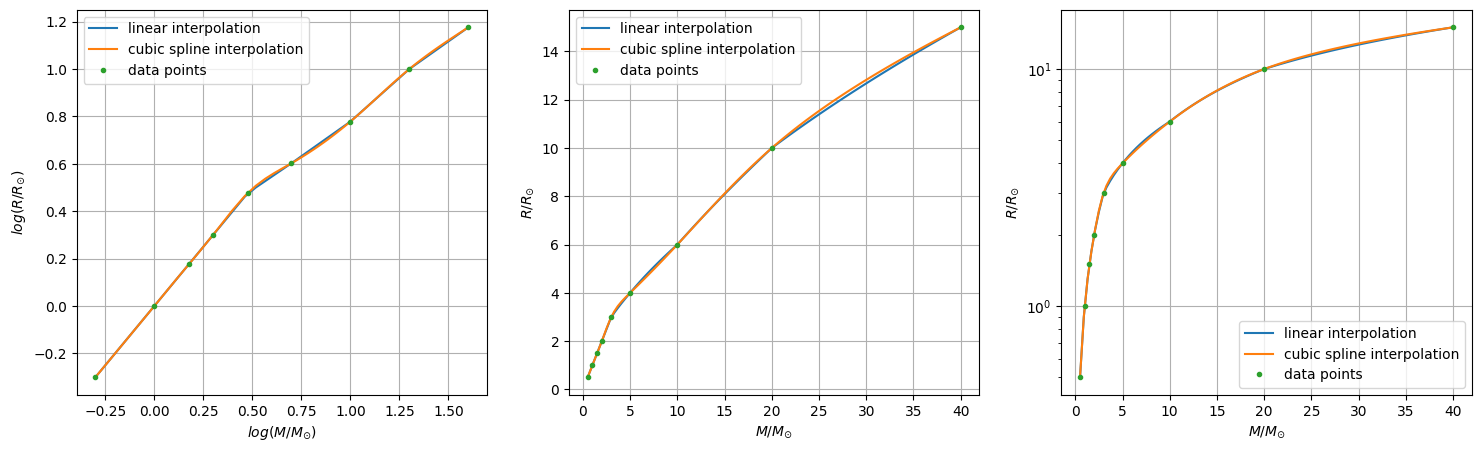

In [167]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x=logquery_xvalues
y1=linear_interpolation([logM,logR],logquery_xvalues)
y2=cubic_spline_interpolation([logM,logR],logquery_xvalues)[0]


axes[0].plot(x,y1,label="linear interpolation")
axes[0].plot(x,y2,label="cubic spline interpolation")

axes[0].plot(logM,logR,".",label="data points")


axes[0].set_xlabel(r"$log(M/M_⊙)$")
axes[0].set_ylabel(r"$log(R/R_⊙)$")

axes[0].legend()
axes[0].grid()

x=10**x
y1=10**y1
y2=10**y2


axes[1].plot(x,y1,label="linear interpolation")
axes[1].plot(x,y2,label="cubic spline interpolation")

axes[1].plot(10**logM,10**logR,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$R/R_⊙$")
#axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

axes[2].plot(x,y1,label="linear interpolation")
axes[2].plot(x,y2,label="cubic spline interpolation")

axes[2].plot(10**logM,10**logR,".",label="data points")


axes[2].set_xlabel(r"$M/M_⊙$")
axes[2].set_ylabel(r"$R/R_⊙$")
axes[2].set_yscale("log")

axes[2].legend()
axes[2].grid()

plt.show()

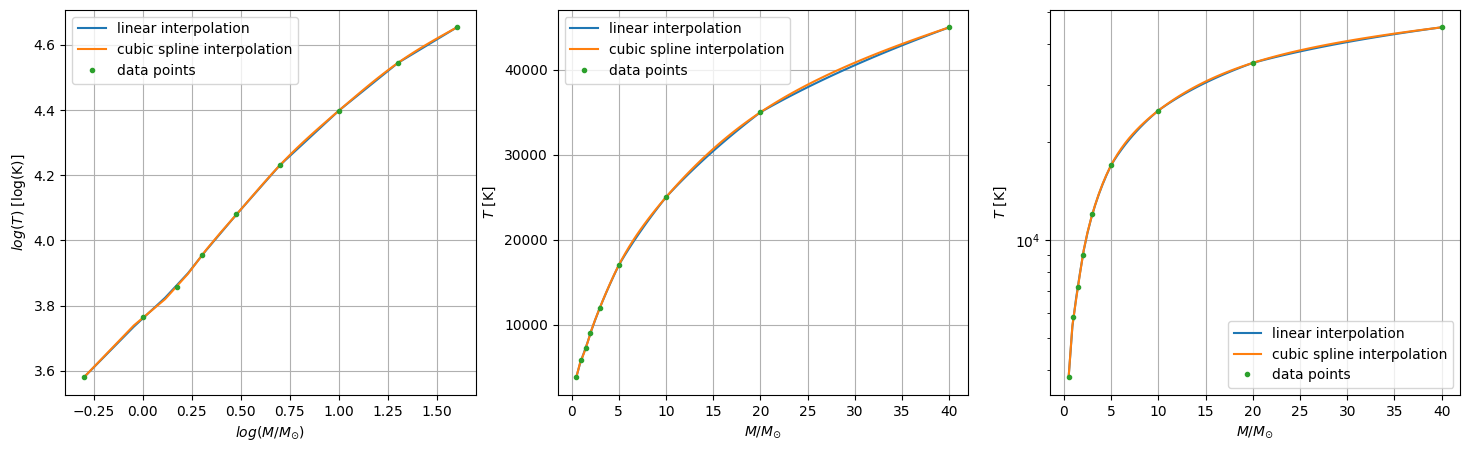

In [178]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x=logquery_xvalues
y1=linear_interpolation([logM,logT],logquery_xvalues)
y2=cubic_spline_interpolation([logM,logT],logquery_xvalues)[0]


axes[0].plot(x,y1,label="linear interpolation")
axes[0].plot(x,y2,label="cubic spline interpolation")

axes[0].plot(logM,logT,".",label="data points")


axes[0].set_xlabel(r"$log(M/M_⊙)$")
axes[0].set_ylabel(r"$log(T)$ [log(K)]")

axes[0].legend()
axes[0].grid()

x=10**x
y1=10**y1
y2=10**y2


axes[1].plot(x,y1,label="linear interpolation")
axes[1].plot(x,y2,label="cubic spline interpolation")

axes[1].plot(10**logM,10**logT,".",label="data points")


axes[1].set_xlabel(r"$M/M_⊙$")
axes[1].set_ylabel(r"$T$ [K]")
#axes[1].set_yscale("log")

axes[1].legend()
axes[1].grid()

axes[2].plot(x,y1,label="linear interpolation")
axes[2].plot(x,y2,label="cubic spline interpolation")

axes[2].plot(10**logM,10**logT,".",label="data points")


axes[2].set_xlabel(r"$M/M_⊙$")
axes[2].set_ylabel(r"$T$ [K]")
axes[2].set_yscale("log")

axes[2].legend()
axes[2].grid()

plt.show()

### Comparison to interpolation in original variables:

In comparison to the interpolation in original variables the log-log interpolation and back transformation doesn't have the problems and describes the curve better.

Linear interpolation in log-log space assumes a linear relation between logQ and logM. Transforming back to the original variables yields a power-law relation Q∝M
a
. Since the interpolation is performed piecewise between data points, the resulting function corresponds to a piecewise power-law approximation.

## Part 5: Lifetime from luminosity

In [190]:
query_xvalues=np.logspace(np.log10(0.5),np.log10(40),100)
M=np.array([0.5,1,1.5,2,3,5,10,20,40])
tau=np.array([56000,10000,3000,1300,400,100,20,5,3])
L=np.array([0.05,1.0,5,25,80,800,10000,100000,500000])


tau_f1=10**4*query_xvalues/linear_interpolation([M,L],query_xvalues)
tau_f2=10**4*query_xvalues/cubic_spline_interpolation([M,L],query_xvalues)[0]

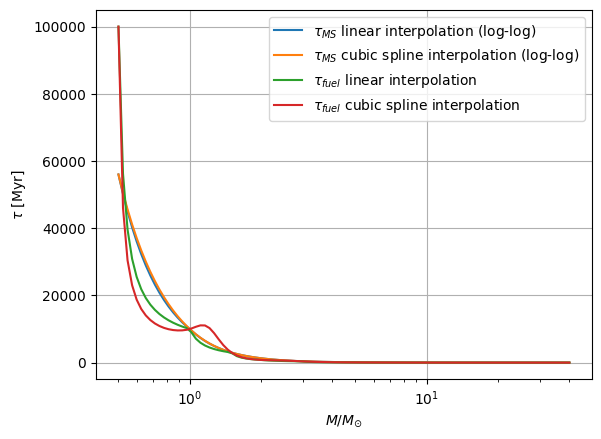

In [199]:
x=np.log10(query_xvalues)
y1=linear_interpolation([logM,logtau],x)
y2=cubic_spline_interpolation([logM,logtau],x)[0]


plt.plot(10**x,10**y1,label=r"$\tau_{MS}$ linear interpolation (log-log)")
plt.plot(10**x,10**y2,label=r"$\tau_{MS}$ cubic spline interpolation (log-log)")

plt.plot(query_xvalues,tau_f1,label=r"$\tau_{fuel}$ linear interpolation")
plt.plot(query_xvalues,tau_f2,label=r"$\tau_{fuel}$ cubic spline interpolation")


plt.xlabel(r"$M/M_⊙$")
plt.ylabel(r"$\tau$ [Myr]")
plt.xscale("log")

plt.legend()
plt.grid()
plt.show()

The assumption that available fuel is proportional to the stellar mass works reasonably well for bigger masses. For smaller masses there are some deviations. In this case the assumption might not be right!

## Part 6: Turn-off mass of a stellar population

In [200]:
def secant(func,params, p1, p2, stop):
    """
    function tries to find roots via secant method
    
    func: function
    params: parameter
    p1: first initial guess
    p2: second initial guess
    stop: stopping criteria for abs(f(pn))
    """
    while abs(func(p2,*params))>stop:
        p2,p1=p2-func(p2,*params)*(p2-p1)/(func(p2,*params)-func(p1,*params)),p2
        print(p2)
    return p2